## B747: обучение модели динамики на ступенчатом управляющем сигнале + MPC (Torch)

Этот ноутбук делает полный цикл:

- создаём `LinearLongitudinalB747-v0` со **ступенчатым опорным сигналом** по тангажу (theta)
- собираем датасет переходов *(x_t, u_t) → x_{t+1}* под **ступенчатым управляющим воздействием** (piecewise constant)
- обучаем one-step модель динамики (MLP на PyTorch) в **нативных единицах модели** (рад)
- запускаем MPC (`TorchMPC`) поверх learned dynamics и смотрим трекинг

> Важно про единицы: `env.step()` принимает действие в **градусах**, а внутренняя модель `LongitudinalB747` работает в **радианах**. В датасете и в MPC мы работаем в радианах.



In [1]:
import numpy as np
import gymnasium as gym

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

from tensoraerospace.signals.standart import unit_step

# Новый MPC (torch/autograd + проекция на ограничения)
from tensoraerospace.agent.mpc.torch_mpc import TorchMPC, TorchMPCWeights, TorchMPCConstraints



In [ ]:
# --- Конфиг (можно спокойно менять) ---
np.random.seed(0)
torch.manual_seed(0)

# Симуляция
DT = 0.1
TN = 20.0
N_STEPS = int(TN / DT) + 1
T = np.arange(N_STEPS, dtype=np.float32) * DT

# Ступенчатый референс theta (в градусах -> unit_step -> рад)
REF_STEP_DEG = 5
REF_STEP_TIME_S = 5  # сек

# Сбор датасета: ступенчатое управление (piecewise constant)
# Важно: чтобы MPC мог давать насыщенные действия,
# собираем данные по всему диапазону B747 [-25, 25] deg.
COLLECT_EPISODES = 40
ACTION_STEP_HOLD_STEPS = 8  # сколько шагов держим одно значение u
ACTION_RANGE_DEG = 25.0      # амплитуда ступенек по управлению

# Обучение dynamics
EPOCHS = 60
BATCH_SIZE = 512
LR = 1e-3
HIDDEN = 128

# MPC
HORIZON = 30
MPC_ITERS = 80
MPC_LR = 0.08

# Веса MPC (в единицах модели: u,w [м/с], q,theta [рад])
# Эти значения дают адекватный трекинг step-сигнала по theta.
W_U = 0.0
W_W = 0.0
W_Q = 0.1
W_THETA = 2000.0
W_ACTION = 0.001
W_DU = 0.01
TERMINAL_WEIGHT = 10.0



In [3]:
# Ступенчатый опорный сигнал (рад), форма (1, N_STEPS)
reference_signal = unit_step(
    tp=T,
    degree=int(REF_STEP_DEG),
    time_step=int(REF_STEP_TIME_S),
    output_rad=True,
).reshape(1, -1)

env = gym.make(
    "LinearLongitudinalB747-v0",
    number_time_steps=N_STEPS,
    initial_state=np.array([[0.0], [0.0], [0.0], [0.0]], dtype=np.float32),
    reference_signal=reference_signal,
    dt=float(DT),
)

obs, info = env.reset()
print("obs shape:", np.asarray(obs).shape)
print("action_space:", env.action_space)
print("reference_signal shape:", env.unwrapped.reference_signal.shape)

# Внутренняя модель (4D) в радианах
print("model state xt shape:", np.asarray(env.unwrapped.model.xt).shape)



obs shape: (4, 1)
action_space: Box(-25.0, 25.0, (1,), float32)
reference_signal shape: (1, 201)
model state xt shape: (4, 1)


/Users/asmazaev/TensorAeroSpace-Origin/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


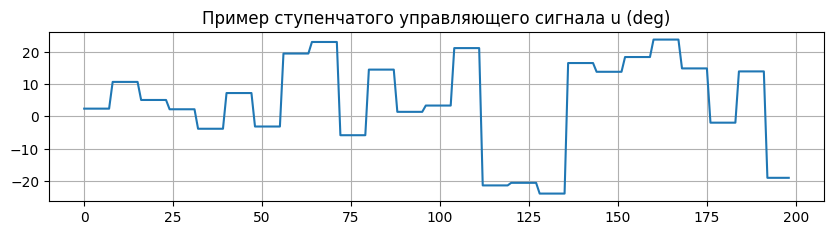

In [4]:
def sample_step_action_deg(
    num_steps: int,
    hold_steps: int,
    action_range_deg: float,
) -> np.ndarray:
    """Piecewise-constant (step-like) action signal in degrees."""
    num_steps = int(num_steps)
    hold_steps = int(max(1, hold_steps))
    n_blocks = int(np.ceil(num_steps / hold_steps))
    values = np.random.uniform(
        -float(action_range_deg),
        float(action_range_deg),
        size=(n_blocks,),
    ).astype(np.float32)
    return np.repeat(values, hold_steps)[:num_steps]


# Визуализация примера управляющего сигнала
_preview = sample_step_action_deg(
    num_steps=min(200, N_STEPS - 2),
    hold_steps=ACTION_STEP_HOLD_STEPS,
    action_range_deg=ACTION_RANGE_DEG,
)
plt.figure(figsize=(10, 2.2))
plt.plot(_preview)
plt.title("Пример ступенчатого управляющего сигнала u (deg)")
plt.grid(True)
plt.show()



In [5]:
def collect_step_dataset(
    env,
    *,
    episodes: int,
    hold_steps: int,
    action_range_deg: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Collect (x_t, u_t)->x_{t+1} data with step-like actions.

    Returns:
        X:  (N, 4) states in model units (rad for angles)
        U:  (N, 1) actions in radians
        XN: (N, 4) next states in model units
    """
    max_steps = int(env.unwrapped.number_time_steps - 2)

    xs: list[np.ndarray] = []
    us: list[float] = []
    xns: list[np.ndarray] = []

    for ep in range(int(episodes)):
        env.reset()
        u_signal_deg = sample_step_action_deg(
            num_steps=max_steps,
            hold_steps=hold_steps,
            action_range_deg=action_range_deg,
        )

        for _ in range(max_steps):
            x_t = np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)
            u_deg = float(u_signal_deg[int(env.unwrapped.current_step)])
            action = np.array([u_deg], dtype=np.float32)

            _obs, _reward, terminated, truncated, _info = env.step(action)
            x_tp1 = np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)

            xs.append(x_t)
            us.append(float(np.deg2rad(u_deg)))
            xns.append(x_tp1)

            if terminated or truncated:
                break

    X = np.asarray(xs, dtype=np.float32)
    U = np.asarray(us, dtype=np.float32).reshape(-1, 1)
    XN = np.asarray(xns, dtype=np.float32)
    return X, U, XN


X, U, XN = collect_step_dataset(
    env,
    episodes=COLLECT_EPISODES,
    hold_steps=ACTION_STEP_HOLD_STEPS,
    action_range_deg=ACTION_RANGE_DEG,
)

print("Dataset shapes:")
print("  X ", X.shape)
print("  U ", U.shape)
print("  XN", XN.shape)

print("Ranges (rough):")
print("  theta(rad):", float(X[:, 3].min()), "..", float(X[:, 3].max()))
print("  u(rad):    ", float(U[:, 0].min()), "..", float(U[:, 0].max()))



/Users/asmazaev/TensorAeroSpace-Origin/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Dataset shapes:
  X  (7960, 4)
  U  (7960, 1)
  XN (7960, 4)
Ranges (rough):
  theta(rad): -1.0203324556350708 .. 1.1498819589614868
  u(rad):     -0.4358558654785156 .. 0.4361652731895447


In [6]:
# Нормализация данных (стабилизирует обучение)
EPS = 1e-6
x_mean = X.mean(axis=0, keepdims=True)
x_std = X.std(axis=0, keepdims=True) + EPS
u_mean = U.mean(axis=0, keepdims=True)
u_std = U.std(axis=0, keepdims=True) + EPS
y_mean = XN.mean(axis=0, keepdims=True)
y_std = XN.std(axis=0, keepdims=True) + EPS

Xn = (X - x_mean) / x_std
Un = (U - u_mean) / u_std
Yn = (XN - y_mean) / y_std

# Готовим тензоры (input=[x,u], target=next_x)
IN = np.concatenate([Xn, Un], axis=1).astype(np.float32)   # (N, 5)
TGT = Yn.astype(np.float32)                                # (N, 4)

# train/val split
n = IN.shape[0]
perm = np.random.permutation(n)
n_train = int(0.8 * n)
train_idx = perm[:n_train]
val_idx = perm[n_train:]

IN_train = torch.tensor(IN[train_idx], dtype=torch.float32)
TGT_train = torch.tensor(TGT[train_idx], dtype=torch.float32)
IN_val = torch.tensor(IN[val_idx], dtype=torch.float32)
TGT_val = torch.tensor(TGT[val_idx], dtype=torch.float32)

print("Train:", IN_train.shape, TGT_train.shape)
print("Val:  ", IN_val.shape, TGT_val.shape)



Train: torch.Size([6368, 5]) torch.Size([6368, 4])
Val:   torch.Size([1592, 5]) torch.Size([1592, 4])


In [7]:
class OneStepMLP(nn.Module):
    def __init__(self, in_dim: int = 5, out_dim: int = 4, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, xu: torch.Tensor) -> torch.Tensor:
        return self.net(xu)


device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print("device:", device)

model = OneStepMLP(in_dim=5, out_dim=4, hidden=HIDDEN).to(device)
opt = torch.optim.Adam(model.parameters(), lr=float(LR))
loss_fn = nn.MSELoss()

train_loader = DataLoader(
    TensorDataset(IN_train, TGT_train),
    batch_size=int(BATCH_SIZE),
    shuffle=True,
)



device: mps


In [8]:
# Обучение
for epoch in range(int(EPOCHS)):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        opt.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        total += float(loss.detach().cpu().item())

    model.eval()
    with torch.no_grad():
        val_pred = model(IN_val.to(device))
        val_loss = float(loss_fn(val_pred, TGT_val.to(device)).detach().cpu().item())

    if epoch % 10 == 0 or epoch == int(EPOCHS) - 1:
        print(
            f"epoch={epoch:03d} "
            f"train_loss={total/len(train_loader):.6f} "
            f"val_loss={val_loss:.6f}"
        )



epoch=000 train_loss=0.921008 val_loss=0.791018
epoch=010 train_loss=0.011030 val_loss=0.009923
epoch=020 train_loss=0.002909 val_loss=0.002771
epoch=030 train_loss=0.000988 val_loss=0.000991
epoch=040 train_loss=0.000575 val_loss=0.000590
epoch=050 train_loss=0.000415 val_loss=0.000430
epoch=060 train_loss=0.000328 val_loss=0.000343
epoch=070 train_loss=0.000274 val_loss=0.000290
epoch=080 train_loss=0.000235 val_loss=0.000252
epoch=090 train_loss=0.000208 val_loss=0.000224
epoch=100 train_loss=0.000187 val_loss=0.000203
epoch=110 train_loss=0.000170 val_loss=0.000185
epoch=119 train_loss=0.000156 val_loss=0.000171


In [ ]:
# Собираем learned dynamics f(x,u)->x_next в исходных единицах (рад)
model_cpu = model.to("cpu").eval()

x_mean_t = torch.tensor(x_mean, dtype=torch.float32)
x_std_t = torch.tensor(x_std, dtype=torch.float32)
u_mean_t = torch.tensor(u_mean, dtype=torch.float32)
u_std_t = torch.tensor(u_std, dtype=torch.float32)
y_mean_t = torch.tensor(y_mean, dtype=torch.float32)
y_std_t = torch.tensor(y_std, dtype=torch.float32)


def learned_dynamics(x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
    # x: (1,4), u: (1,1) in physical units
    x_n = (x - x_mean_t) / x_std_t
    u_n = (u - u_mean_t) / u_std_t
    xu_n = torch.cat([x_n, u_n], dim=-1)  # (1,5)
    y_n = model_cpu(xu_n)
    y = y_n * y_std_t + y_mean_t
    return y


# Ограничения берём из B747 модели (рад)
b747_model = env.unwrapped.model
u_lim = float(np.asarray(b747_model.input_magnitude_limits).reshape(-1)[0])
rate_lim = float(np.asarray(b747_model.input_rate_limits).reshape(-1)[0])
du_max = float(rate_lim * DT)

weights = TorchMPCWeights(
    Q_diag=np.array([W_U, W_W, W_Q, W_THETA], dtype=np.float32),
    R_diag=np.array([W_ACTION], dtype=np.float32),
    S_diag=np.array([W_DU], dtype=np.float32),
    terminal_weight=float(TERMINAL_WEIGHT),
)
constraints = TorchMPCConstraints(
    u_min=np.array([-u_lim], dtype=np.float32),
    u_max=np.array([u_lim], dtype=np.float32),
    du_min=np.array([-du_max], dtype=np.float32),
    du_max=np.array([du_max], dtype=np.float32),
)

mpc = TorchMPC(
    dynamics=learned_dynamics,
    state_dim=4,
    action_dim=1,
    horizon=int(HORIZON),
    weights=weights,
    constraints=constraints,
    iters=int(MPC_ITERS),
    lr=float(MPC_LR),
    optimizer="adam",
    device="cpu",
    warm_start=True,
    seed=0,
)

print("u_lim(rad)=", u_lim, "du_max(rad/step)=", du_max)



DYNAMICS_MODE= true u_lim(deg)= 25.0 du_max(deg/step)= 3.0


In [ ]:
def slice_ref_theta(ref: np.ndarray, start: int, length: int) -> np.ndarray:
    ref = np.asarray(ref, dtype=np.float32).reshape(-1)
    start = int(max(0, start))
    end = start + int(length)
    chunk = ref[start:end]
    if chunk.size >= length:
        return chunk
    pad_val = float(chunk[-1] if chunk.size else ref[-1])
    pad = np.full((length - chunk.size,), pad_val, dtype=np.float32)
    return np.concatenate([chunk, pad], axis=0)


from tqdm.auto import tqdm


# Запуск MPC в среде
obs, info = env.reset()
mpc.reset()

u_prev = np.array([0.0], dtype=np.float32)  # предыдущий u в рад

hist_theta_deg = []
hist_ref_deg = []
hist_u_deg = []

max_steps = int(env.unwrapped.number_time_steps - 2)
ref_theta_rad = np.asarray(env.unwrapped.reference_signal, dtype=np.float32).reshape(1, -1)[0]

for _ in tqdm(range(max_steps), desc="MPC rollout"):
    k = int(env.unwrapped.current_step)  # индекс ДО шага

    x0 = np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)

    theta_ref_h = slice_ref_theta(ref_theta_rad, start=k, length=int(HORIZON) + 1)
    x_ref = np.zeros((int(HORIZON) + 1, 4), dtype=np.float32)
    x_ref[:, 3] = theta_ref_h

    res = mpc.solve(x0=x0, x_ref=x_ref, u_prev=u_prev)
    u0_rad = float(res.u0[0])
    u_prev = np.array([u0_rad], dtype=np.float32)

    u0_deg = float(np.rad2deg(u0_rad))
    action = np.array([np.clip(u0_deg, -25.0, 25.0)], dtype=np.float32)

    _obs, reward, terminated, truncated, _info = env.step(action)

    # После env.step: model.xt = x_{k+1}, current_step = k+1
    k1 = int(env.unwrapped.current_step)
    theta_deg = float(np.rad2deg(np.asarray(env.unwrapped.model.xt).reshape(-1)[3]))
    ref_deg = float(np.rad2deg(ref_theta_rad[min(k1, ref_theta_rad.shape[0] - 1)]))

    hist_theta_deg.append(theta_deg)
    hist_ref_deg.append(ref_deg)
    hist_u_deg.append(float(action[0]))

    if terminated or truncated:
        break

print("steps:", len(hist_theta_deg), "last reward:", reward)



MPC rollout:   0%|          | 0/199 [00:00<?, ?it/s]

steps: 199 last reward: -95236.90304565491


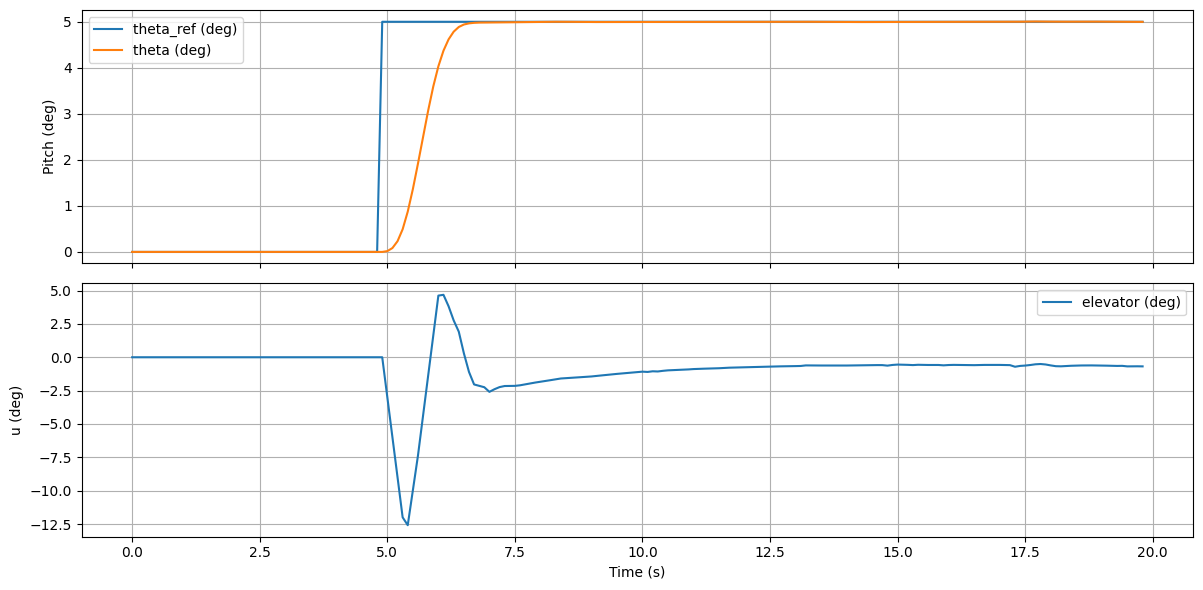

In [11]:
t_plot = np.arange(len(hist_theta_deg), dtype=np.float32) * float(DT)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_plot, hist_ref_deg, label="theta_ref (deg)")
axes[0].plot(t_plot, hist_theta_deg, label="theta (deg)")
axes[0].set_ylabel("Pitch (deg)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t_plot, hist_u_deg, label="elevator (deg)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("u (deg)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()



           step_time_s: 4.9
         overshoot_deg: 0.005606174468994141
       settling_time_s: 1.6
steady_state_error_deg: 0.0022711753845214844
              band_deg: 0.1
            max_du_deg: 3.000000238418579
           max_ddu_deg: 3.1949567794799805
             u_min_deg: -12.589502334594727
             u_max_deg: 4.681094169616699


📊 ControlBenchmark metrics
        damping_degree: -8.207559585571289e-05
                   iae: 43.66301727294922
                   ise: 170.28428649902344
                  itae: 21.799851655960087
     maximum_deviation: 4.999999523162842
     oscillation_count: 4
             overshoot: 0.11212349636480212
             peak_time: 3.5
     performance_index: 76.85607996126637
             rise_time: 0.8
         settling_time: 1.4000000000000001
          static_error: -0.0007829666137695312
    steady_state_value: 4.999999523162842


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: B747 TorchMPC                                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║    